<a href="https://colab.research.google.com/github/mcchezzy/python-data-analysis-journey/blob/main/Salary_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


### Load Dataset

In [3]:
# Let's Read Dataset
df = pd.read_csv("/content/drive/MyDrive/TechCrush_C7_AI/Datasets/salary_dataset.csv")

# View the first 5
df.head()

,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
0,1,44,26,13.0,Sales,Bachelor,4.0,160.0,167000.0
1,2,38,18,0.0,Engineering,Bachelor,4.0,163.0,174000.0
2,3,46,24,3.0,Sales,Master,5.0,159.0,223000.0
3,4,55,31,12.0,Engineering,High School,1.0,148.0,125000.0
4,5,37,17,11.0,HR,Bachelor,2.0,172.0,115000.0


In [4]:
# view the last 5
df.tail()



,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
995,996,37,18,9.0,Sales,Bachelor,4.0,161.0,159000.0
996,997,57,34,14.0,Operations,Bachelor,4.0,161.0,157000.0
997,998,46,21,2.0,Engineering,Master,2.0,160.0,194000.0
998,999,34,11,4.0,Engineering,High School,2.0,156.0,112000.0
999,1000,45,20,0.0,Marketing,Master,1.0,195.0,128000.0


In [5]:
df.shape

(1000, 9)

### Data Cleaning and Preprocessing

In [49]:
# check the data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1000 non-null   int64  
 1   YearsExperience             1000 non-null   int64  
 2   YearsAtCompany              1000 non-null   float64
 3   PerformanceRating           1000 non-null   float64
 4   MonthlyHoursWorked          1000 non-null   float64
 5   MonthlySalary               1000 non-null   float64
 6   Department_Finance          1000 non-null   bool   
 7   Department_HR               1000 non-null   bool   
 8   Department_Marketing        1000 non-null   bool   
 9   Department_Operations       1000 non-null   bool   
 10  Department_Sales            1000 non-null   bool   
 11  EducationLevel_High School  1000 non-null   bool   
 12  EducationLevel_Master       1000 non-null   bool   
 13  EducationLevel_PhD          1000 n

In [50]:
# Display statistical summary
df.describe()

,Age,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,MonthlySalary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.764000,17.435000,3.655000,3.238000,169.631000,152093.000000
std,9.489381,9.650021,3.963292,0.957221,14.159072,42559.883631
min,22.000000,0.000000,0.000000,1.000000,140.000000,70000.000000
25%,33.000000,11.000000,1.000000,3.000000,160.000000,121000.000000
50%,40.000000,17.000000,2.000000,3.000000,170.000000,147000.000000
75%,46.000000,24.000000,5.000000,4.000000,179.000000,176000.000000
max,65.000000,47.000000,22.000000,5.000000,216.000000,317000.000000


In [51]:
# checking for missing values
df.isnull().sum()

,0
Age,0
YearsExperience,0
YearsAtCompany,0
PerformanceRating,0
MonthlyHoursWorked,0
MonthlySalary,0
Department_Finance,0
Department_HR,0
Department_Marketing,0
Department_Operations,0


In [56]:
# Calculate the median of each columns and median to fills all the missing values
df.median(numeric_only=True)

,0
Age,40.0
YearsExperience,17.0
YearsAtCompany,2.0
PerformanceRating,3.0
MonthlyHoursWorked,170.0
MonthlySalary,147000.0
Department_Finance,0.0
Department_HR,0.0
Department_Marketing,0.0
Department_Operations,0.0


In [57]:
# Calculate the median of each columns and median to fills all the missing values
median_years = df["YearsAtCompany"].median()
median_rating = df["PerformanceRating"].median()
median_hours = df["MonthlyHoursWorked"].median()


In [58]:
df["YearsAtCompany"] = df["YearsAtCompany"].fillna(median_years)
df["PerformanceRating"] = df["PerformanceRating"].fillna(median_rating)
df["MonthlyHoursWorked"] = df["MonthlyHoursWorked"].fillna(median_hours)

In [59]:
# Confirm no missing values
df.isnull().sum()

,0
Age,0
YearsExperience,0
YearsAtCompany,0
PerformanceRating,0
MonthlyHoursWorked,0
MonthlySalary,0
Department_Finance,0
Department_HR,0
Department_Marketing,0
Department_Operations,0


In [60]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [61]:
# Display column names
df.columns



Index(['Age', 'YearsExperience', 'YearsAtCompany', 'PerformanceRating',
       'MonthlyHoursWorked', 'MonthlySalary', 'Department_Finance',
       'Department_HR', 'Department_Marketing', 'Department_Operations',
       'Department_Sales', 'EducationLevel_High School',
       'EducationLevel_Master', 'EducationLevel_PhD'],
      dtype='object')

* Encode Catergorical features ('Department' and 'EducationLevel') are categories, RandomForest needs numeric input, so we'll **one-hot encoding** via pd.get_dummies

In [62]:
df.columns

Index(['Age', 'YearsExperience', 'YearsAtCompany', 'PerformanceRating',
       'MonthlyHoursWorked', 'MonthlySalary', 'Department_Finance',
       'Department_HR', 'Department_Marketing', 'Department_Operations',
       'Department_Sales', 'EducationLevel_High School',
       'EducationLevel_Master', 'EducationLevel_PhD'],
      dtype='object')

### Feature Engineering

In [63]:
# Define features (X) and target variable (y)
X = df.drop(columns=["MonthlySalary"])  # Drop the target variable from the DataFrame so we'll be left with features
y = df["MonthlySalary"]  # Target/Dependent variable

In [64]:
X.head()

,Age,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
0,44,26,13.0,4.0,160.0,False,False,False,False,True,False,False,False
1,38,18,0.0,4.0,163.0,False,False,False,False,False,False,False,False
2,46,24,3.0,5.0,159.0,False,False,False,False,True,False,True,False
3,55,31,12.0,1.0,148.0,False,False,False,False,False,True,False,False
4,37,17,11.0,2.0,172.0,False,True,False,False,False,False,False,False


In [65]:
y.head()

,MonthlySalary
0,167000.0
1,174000.0
2,223000.0
3,125000.0
4,115000.0


## Split Dataset

In [66]:
# split dataset into test and train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
print("X_train train:", X_train.shape)
print("X_test text:", X_test.shape)
print("y_train train:", y_train.shape)
print("y_test text:", y_test.shape)

X_train train: (800, 13)
X_test text: (200, 13)
y_train train: (800,)
y_test text: (200,)


In [68]:
df.head()

,Age,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,MonthlySalary,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
0,44,26,13.0,4.0,160.0,167000.0,False,False,False,False,True,False,False,False
1,38,18,0.0,4.0,163.0,174000.0,False,False,False,False,False,False,False,False
2,46,24,3.0,5.0,159.0,223000.0,False,False,False,False,True,False,True,False
3,55,31,12.0,1.0,148.0,125000.0,False,False,False,False,False,True,False,False
4,37,17,11.0,2.0,172.0,115000.0,False,True,False,False,False,False,False,False


### Train Model

In [69]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [70]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

* Predicts y_test

In [74]:
# Lets predict the test data of MonthlySalary
y_pred = model.predict(X_test)
y_pred

array([172770., 191100.,  85030., 109010., 101360., 173150., 167380.,
       159920., 103930., 182140., 142590., 177100., 127440., 108830.,
       114770., 180420., 180210., 116360., 197550., 141240., 111040.,
       164360., 166420., 125210., 164870., 136470., 149570., 167260.,
       126770., 161560., 127800., 114480., 121960., 112270., 193060.,
       158860., 147090., 135550., 170160., 137400., 150790., 217510.,
       206060., 173940., 135780.,  91340., 160690., 148700., 139800.,
       102890., 125450., 133760., 147770., 137640., 121130., 188320.,
       122370., 152250., 103780., 165930., 129730., 229440., 152270.,
       146780., 236580., 187060., 115330., 107650., 136150., 123540.,
       124820., 102210., 190360., 174500., 162710., 114040., 150280.,
       202240., 132850., 104450., 235640., 123710., 169220., 136270.,
       131500., 114880., 106210., 123460., 177660., 149330., 141430.,
       117420., 131960., 143090., 172820., 169490., 186720., 147470.,
        90030., 1392

* Visual of the Actual vs Predicted

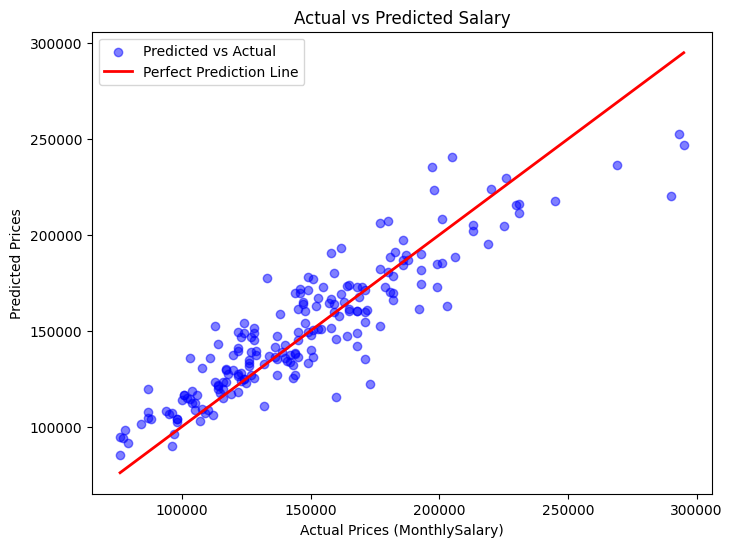

In [76]:
# Let's see the scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r", lw=2, label="Perfect Prediction Line")
plt.xlabel("Actual Prices (MonthlySalary)")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()

**Compare the Outcome of Predicted Value to the Actual Value**

In [77]:
# Compare the outcome of prediction and actual
df_result = pd.DataFrame({"Actual(y)": y_test, "Predicted(y)": y_pred})
df_result.head()

,Actual(y),Predicted(y)
521,168000.0,172770.0
737,183000.0,191100.0
740,76000.0,85030.0
660,108000.0,109010.0
411,84000.0,101360.0


**Check the Difference Between Actual vs Predicted**

In [78]:
diff = pd.DataFrame({"Difference": abs(y_test - y_pred)})   # Creates a DataFrame of difference between actual and predicted
df_result["Difference(residual)"] = diff["Difference"]    # Creates the differece btw actual vs predictes as a new column
df_result.head()


,Actual(y),Predicted(y),Difference(residual)
521,168000.0,172770.0,4770.0
737,183000.0,191100.0,8100.0
740,76000.0,85030.0,9030.0
660,108000.0,109010.0,1010.0
411,84000.0,101360.0,17360.0


In [83]:
# Compare the difference btw actual vs predicted
#df_result["Difference"] = abs(df_result["Actual(y)"] - df_result["Predicted(y)"])
#df_result.head()

## Evaluate Model

* Calculate the Metrics

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [85]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

* Print Metrics

In [86]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 13374.6
Mean Squared Error: 310312169.0
Root Mean Squared Error: 17615.679634916163
R² Score: 0.8131927947680502


* Visualize Important features

In [88]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,PerformanceRating,0.154738
1,YearsExperience,0.136771
12,EducationLevel_PhD,0.117073
11,EducationLevel_Master,0.114943
0,Age,0.098315
10,EducationLevel_High School,0.076429
6,Department_HR,0.057005
8,Department_Operations,0.051841
2,YearsAtCompany,0.051607
4,MonthlyHoursWorked,0.048376


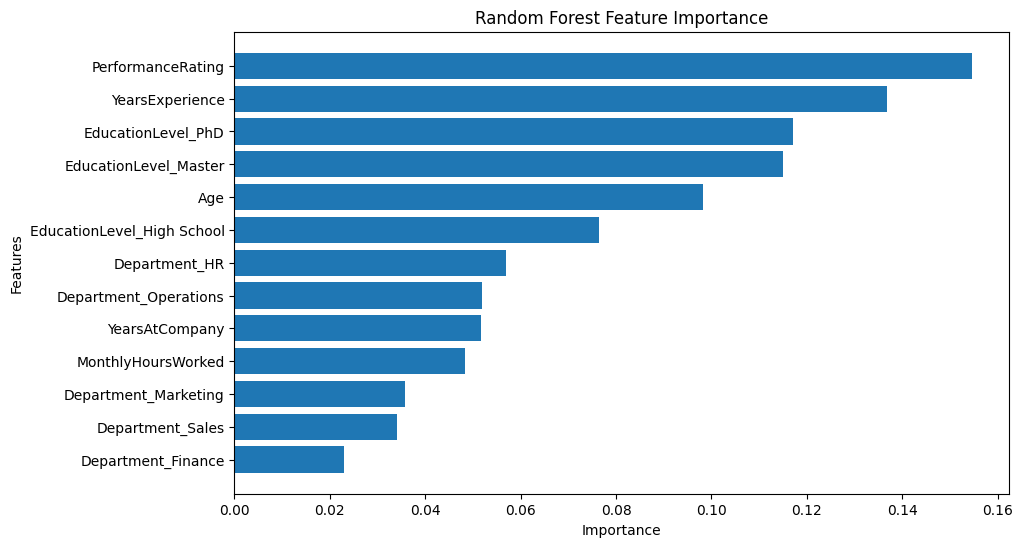

In [89]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values("Importance")

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [90]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")

['salary_prediction_model.pkl']